# Feedforward Neural Network

This notebook implements and analyzes a feedforward neural network with several nonlinear hidden layers.

## Dataset Description
The Car Evaluation dataset contains 6 monotonic criteria and 4 ordered classes: `unacc < acc < good < vgood`.

Criteria:
- `buying` (gain)
- `maint` (gain)
- `doors` (gain)
- `persons` (gain)
- `lug_boot` (gain)
- `safety` (gain)

All criteria are already ordinally encoded to `[0, 1]` levels.

In [14]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

from models.neural_network import NeuralNetwork, train_neural_network


In [15]:
data = pd.read_csv(project_root / "data" / "car-evaluation.csv", header=None)
X = data.iloc[:, :6].to_numpy(dtype=np.float32)
y = data.iloc[:, 6].to_numpy(dtype=np.int64) - 1 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train/test shapes:", X_train.shape, X_test.shape)
print("Train class counts:", np.bincount(y_train))
print("Test class counts: ", np.bincount(y_test))


Train/test shapes: (1382, 6) (346, 6)
Train class counts: [968 307  55  52]
Test class counts:  [242  77  14  13]


## Train Neural Network and Evaluate Performance
We train a feedforward neural network with 3 hidden layers (64-128-64), BatchNorm, ReLU activations, and Dropout.
Class weights are computed from training data to address class imbalance.
Early stopping monitors test AUC.

In [16]:
cw = compute_class_weight("balanced", classes=np.arange(4), y=y_train)
print("Class weights:", np.round(cw, 4))

device = "mps" if torch.backends.mps.is_available() else "cpu"
print("Device:", device)

model = NeuralNetwork(
    num_features=6, num_classes=4,
    hidden_sizes=(64, 128, 64), dropout=0.3,
)

history = train_neural_network(
    model,
    X_train, y_train,
    X_test, y_test,
    epochs=300,
    lr=3e-3,
    batch_size=256,
    device=device,
    early_stopping_patience=30,
    monitor="test_auc",
    class_weights=cw,
)
print(f"Best epoch: {model.best_epoch_}")


Class weights: [0.3569 1.1254 6.2818 6.6442]
Device: mps


Training Neural Network:  67%|██████▋   | 202/300 [00:12<00:06, 15.61it/s]

Best epoch: 172


In [17]:
dev = torch.device(device)
model = model.to(dev)
model.eval()

x_test_t = torch.tensor(X_test, dtype=torch.float32, device=dev)
with torch.no_grad():
    y_pred = model.predict(x_test_t).cpu().numpy()
    y_proba = model.predict_proba(x_test_t).cpu().numpy()

y_test_oh = np.eye(4)[y_test]
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
auc = roc_auc_score(y_test_oh, y_proba, multi_class="ovr", average="macro")

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {f1:.4f}")
print(f"OVR AUC: {auc:.4f}")


Accuracy: 0.9769
Macro F1: 0.9835
OVR AUC: 1.0000


## Training Dynamics
The plots below verify convergence and show generalization behavior across train/test sets.

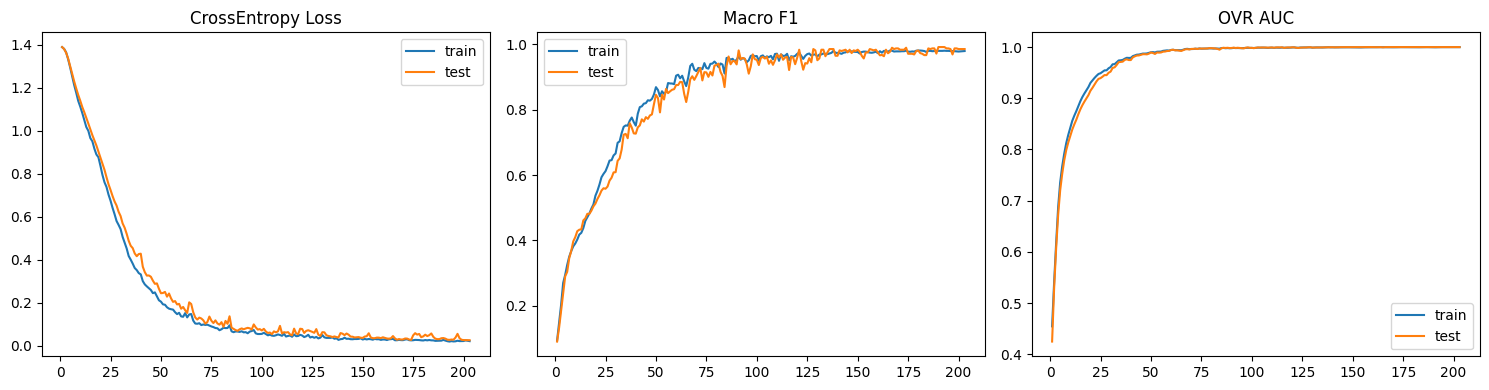

In [18]:
epochs = np.arange(1, len(history.train_loss) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, history.train_loss, label="train")
axes[0].plot(epochs, history.test_loss, label="test")
axes[0].set_title("CrossEntropy Loss")
axes[0].legend()

axes[1].plot(epochs, history.train_f1, label="train")
axes[1].plot(epochs, history.test_f1, label="test")
axes[1].set_title("Macro F1")
axes[1].legend()

axes[2].plot(epochs, history.train_auc, label="train")
axes[2].plot(epochs, history.test_auc, label="test")
axes[2].set_title("OVR AUC")
axes[2].legend()

plt.tight_layout()


## 2.1 Explanation of Decisions for 3 Selected Alternatives
For three selected alternatives (indices `613`, `750`, `1416`) we:
1. Show the predicted class and class probabilities.
2. Compute ICE curves for local explanation.
3. Find the minimum single-criterion change to flip the predicted class:
   - **Analytically**: use the Jacobian to estimate sensitivity per criterion, then verify on the discrete grid.
   - **Sampling**: exhaustively try all possible single-criterion discrete-level substitutions.
4. Compare results from both approaches.

In [19]:
criteria_names = ["buying", "maint", "doors", "persons", "lug_boot", "safety"]
levels_per_criterion = {
    0: [0.0, 1/3, 2/3, 1.0],
    1: [0.0, 1/3, 2/3, 1.0],
    2: [0.0, 1/3, 2/3, 1.0],
    3: [0.0, 0.5, 1.0],
    4: [0.0, 0.5, 1.0],
    5: [0.0, 0.5, 1.0],
}

class_names = ["unacc", "acc", "good", "vgood"]
indices = [613, 750, 1416]

for idx in indices:
    x = X[idx:idx+1].copy()
    xb = torch.tensor(x, dtype=torch.float32, device=dev)
    with torch.no_grad():
        pred = int(model.predict(xb).item())
        proba = model.predict_proba(xb).cpu().numpy()[0]

    print(f"\n{'='*60}")
    print(f"Alternative index: {idx}")
    print(f"Input levels: {np.round(x[0], 4)}")
    print(f"Predicted class: {pred} ({class_names[pred]})")
    print(f"Class probabilities: {np.round(proba, 4)}")

    xj = torch.tensor(x, dtype=torch.float32, device=dev, requires_grad=True)
    model.eval()
    logits = model(xj)
    logits[0, pred].backward()
    grad = xj.grad.detach().cpu().numpy()[0]
    print(f"Jacobian (d logit[{pred}] / d input): {np.round(grad, 4)}")

    print("Analytical minimal one-criterion change (discrete levels):")
    for ci in range(6):
        cur = float(x[0, ci])
        best = None
        for lvl in levels_per_criterion[ci]:
            if abs(lvl - cur) < 1e-6:
                continue
            x_new = x.copy()
            x_new[0, ci] = lvl
            xb_new = torch.tensor(x_new, dtype=torch.float32, device=dev)
            with torch.no_grad():
                y_new = int(model.predict(xb_new).item())
            if y_new != pred:
                step = abs(lvl - cur)
                if best is None or step < best[0]:
                    best = (step, cur, lvl, y_new)
        if best is None:
            print(f"  {criteria_names[ci]}: no single-criterion change flips class")
        else:
            step, cur_v, lvl_v, y_new = best
            print(f"  {criteria_names[ci]}: change {cur_v:.4f} -> {lvl_v:.4f} (step={step:.4f}) -> new class {y_new} ({class_names[y_new]})")

    print("Sampling minimal one-criterion change (one-step neighbors):")
    for ci in range(6):
        cur = float(x[0, ci])
        lvls = levels_per_criterion[ci]
        # Find nearest index
        dists = [abs(l - cur) for l in lvls]
        pos = int(np.argmin(dists))
        neighbors = []
        if pos + 1 < len(lvls):
            neighbors.append(lvls[pos + 1])
        if pos - 1 >= 0:
            neighbors.append(lvls[pos - 1])
        found = None
        for nl in neighbors:
            x_new = x.copy()
            x_new[0, ci] = nl
            xb_new = torch.tensor(x_new, dtype=torch.float32, device=dev)
            with torch.no_grad():
                y_new = int(model.predict(xb_new).item())
            if y_new != pred:
                found = (nl - cur, cur, nl, y_new)
                break
        if found is None:
            print(f"  {criteria_names[ci]}: neighbor steps do not flip class")
        else:
            step, cur_v, nl_v, y_new = found
            print(f"  {criteria_names[ci]}: change {cur_v:.4f} -> {nl_v:.4f} -> new class {y_new} ({class_names[y_new]})")



Alternative index: 613
Input levels: [0.6667 0.6667 0.6667 1.     0.     0.5   ]
Predicted class: 0 (unacc)
Class probabilities: [9.682e-01 3.140e-02 0.000e+00 3.000e-04]
Jacobian (d logit[0] / d input): [-2.0568  0.2419 -0.5966 -0.1264 -9.0085 -3.1016]
Analytical minimal one-criterion change (discrete levels):
  buying: change 0.6667 -> 0.0000 (step=0.6667) -> new class 1 (acc)
  maint: no single-criterion change flips class
  doors: no single-criterion change flips class
  persons: no single-criterion change flips class
  lug_boot: change 0.0000 -> 0.5000 (step=0.5000) -> new class 1 (acc)
  safety: change 0.5000 -> 1.0000 (step=0.5000) -> new class 1 (acc)
Sampling minimal one-criterion change (one-step neighbors):
  buying: neighbor steps do not flip class
  maint: neighbor steps do not flip class
  doors: neighbor steps do not flip class
  persons: neighbor steps do not flip class
  lug_boot: change 0.0000 -> 0.5000 -> new class 1 (acc)
  safety: change 0.5000 -> 1.0000 -> new cl

### ICE Plots for Selected Alternatives
Individual Conditional Expectation plots show how predicted class probability changes when varying a single criterion while holding others fixed.

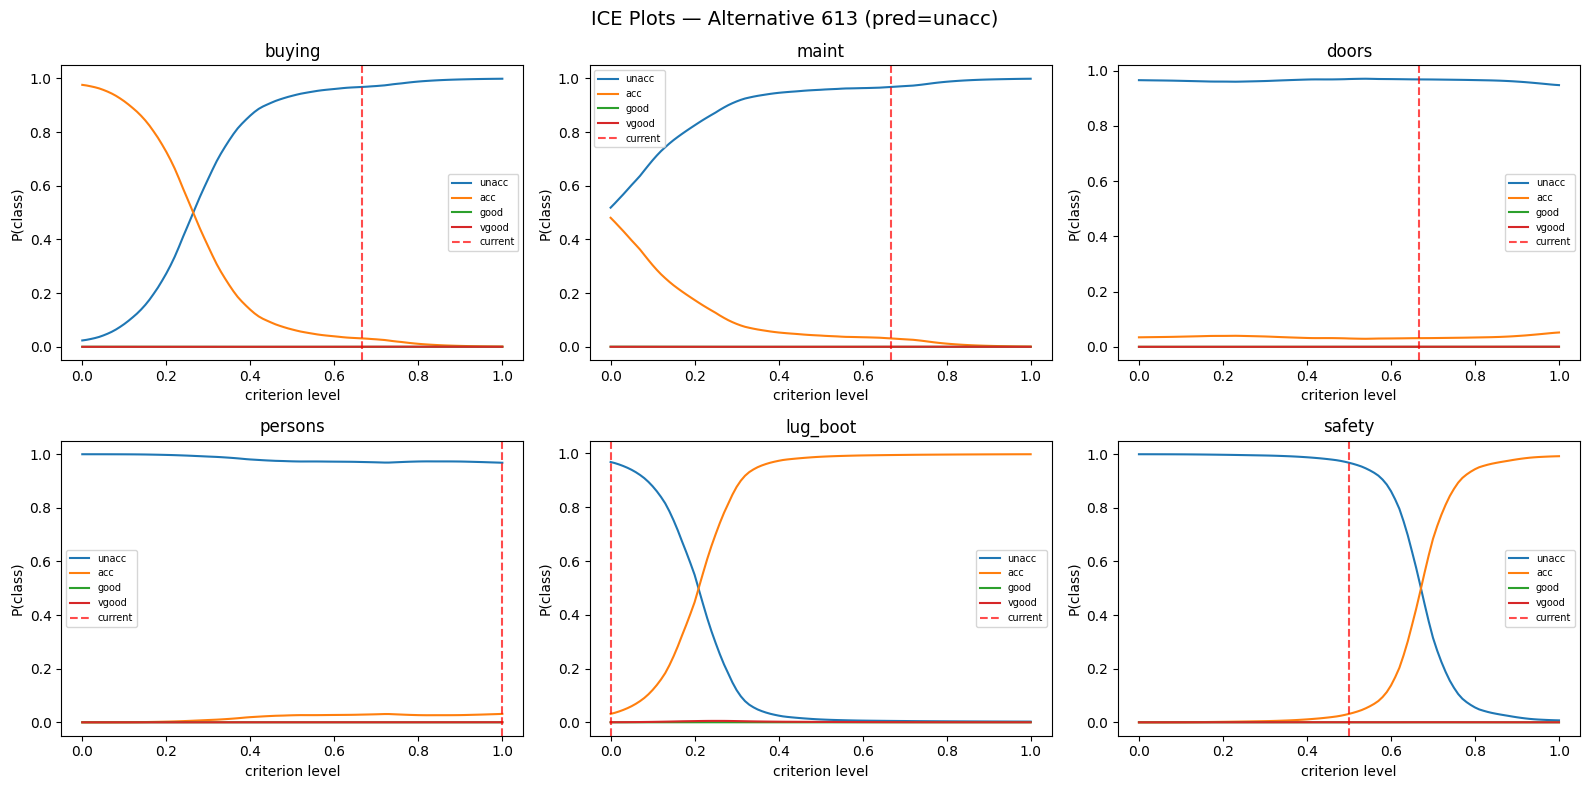

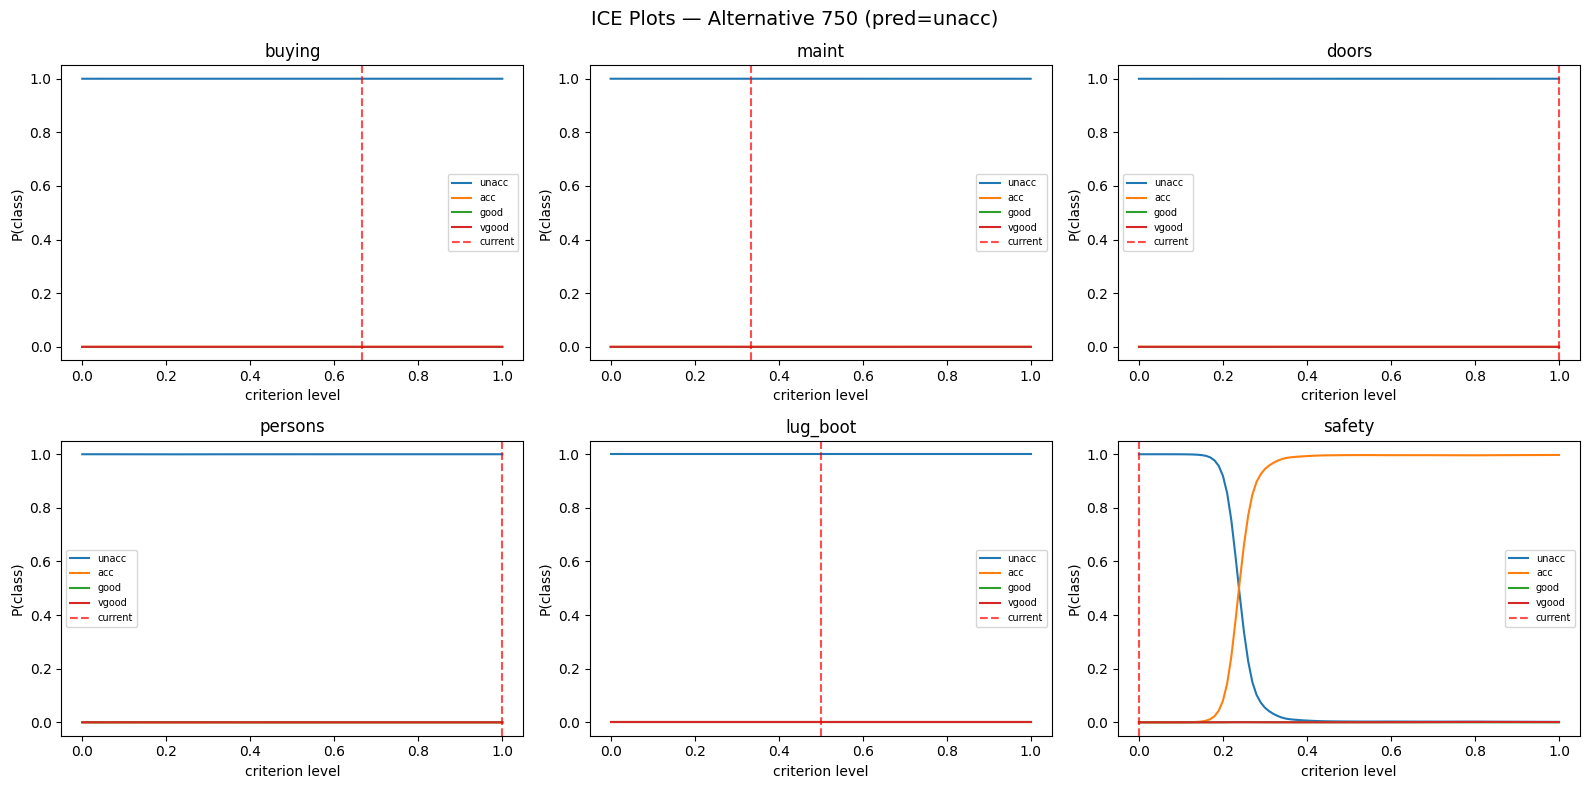

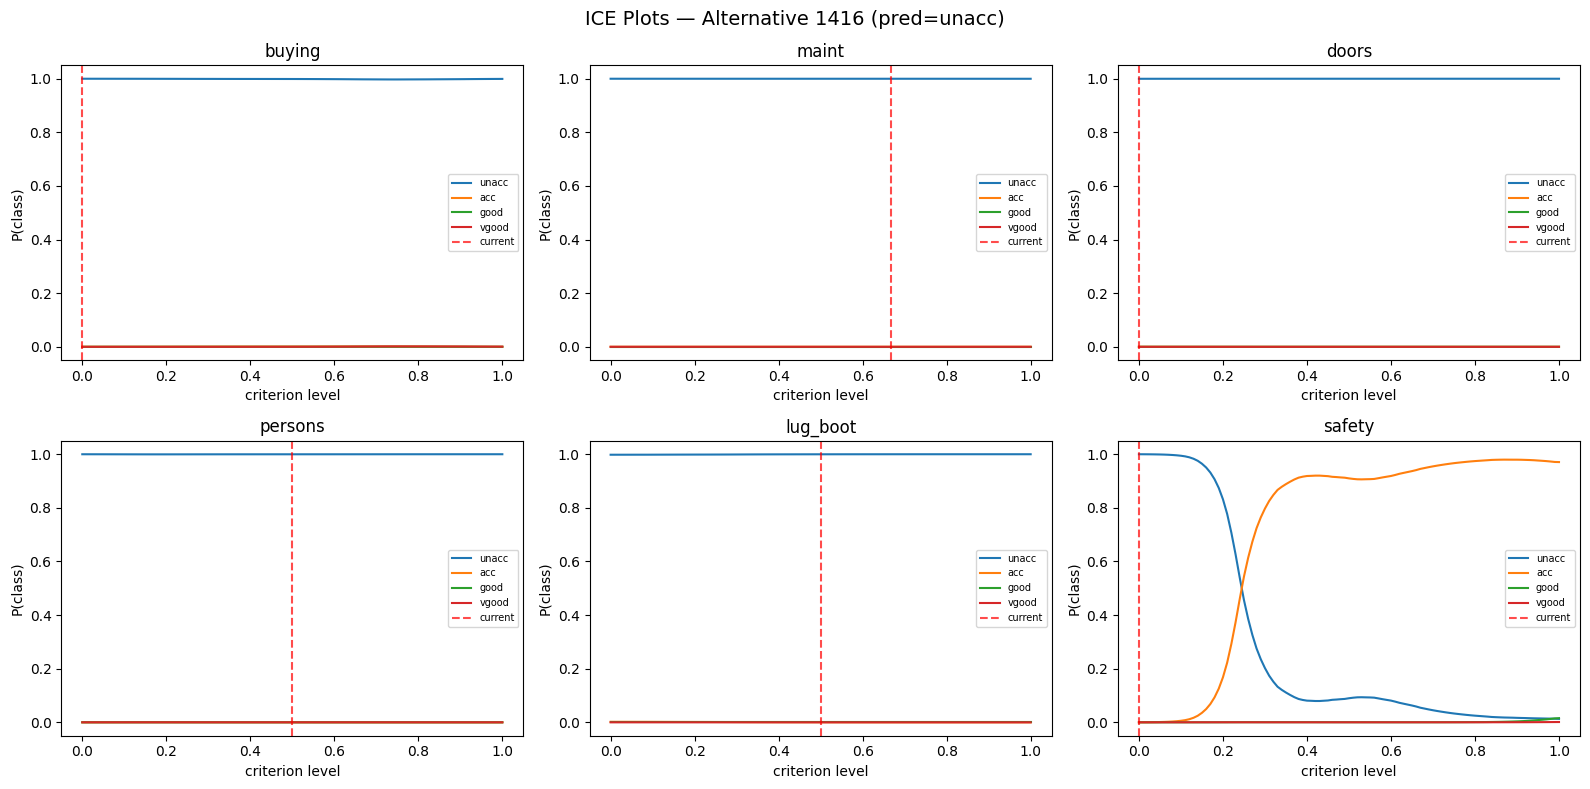

In [20]:
grid_points = np.linspace(0.0, 1.0, 101)

for idx in indices:
    x = X[idx:idx+1].copy()
    with torch.no_grad():
        pred = int(model.predict(torch.tensor(x, dtype=torch.float32, device=dev)).item())

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle(f"ICE Plots — Alternative {idx} (pred={class_names[pred]})", fontsize=14)

    for ci, ax in enumerate(axes.ravel()):
        probs_curve = []
        for val in grid_points:
            x_mod = x.copy()
            x_mod[0, ci] = val
            xb = torch.tensor(x_mod, dtype=torch.float32, device=dev)
            with torch.no_grad():
                p = model.predict_proba(xb).cpu().numpy()[0]
            probs_curve.append(p)
        probs_curve = np.array(probs_curve)
        for cls_i in range(4):
            ax.plot(grid_points, probs_curve[:, cls_i], label=class_names[cls_i])
        ax.axvline(x=x[0, ci], color="red", linestyle="--", alpha=0.7, label="current")
        ax.set_title(criteria_names[ci])
        ax.set_xlabel("criterion level")
        ax.set_ylabel("P(class)")
        ax.legend(fontsize=7)

    plt.tight_layout()


## 2.2 Interpretation of the Model
We analyze the model's learned preferences using:
1. **Partial Dependence Plots** to understand criterion nature (gain, cost, non-monotonic) and preference thresholds.
2. **Interaction heatmap** safety × persons to check for dependencies between criteria.
3. **Weight analysis** of the first hidden layer.

In [21]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import permutation_importance


class NNSklearnWrapper(BaseEstimator, ClassifierMixin):
    """Thin sklearn-compatible wrapper around the PyTorch NeuralNetwork."""
    def __init__(self, nn_model, device):
        self.nn_model = nn_model
        self.device = device
        self.classes_ = np.arange(nn_model.num_classes)

    def fit(self, X, y):
        return self  # already trained

    def predict(self, X):
        xb = torch.tensor(np.asarray(X, dtype=np.float32), device=self.device)
        return self.nn_model.predict(xb).cpu().numpy()

    def predict_proba(self, X):
        xb = torch.tensor(np.asarray(X, dtype=np.float32), device=self.device)
        return self.nn_model.predict_proba(xb).cpu().numpy()


wrapper = NNSklearnWrapper(model, dev)


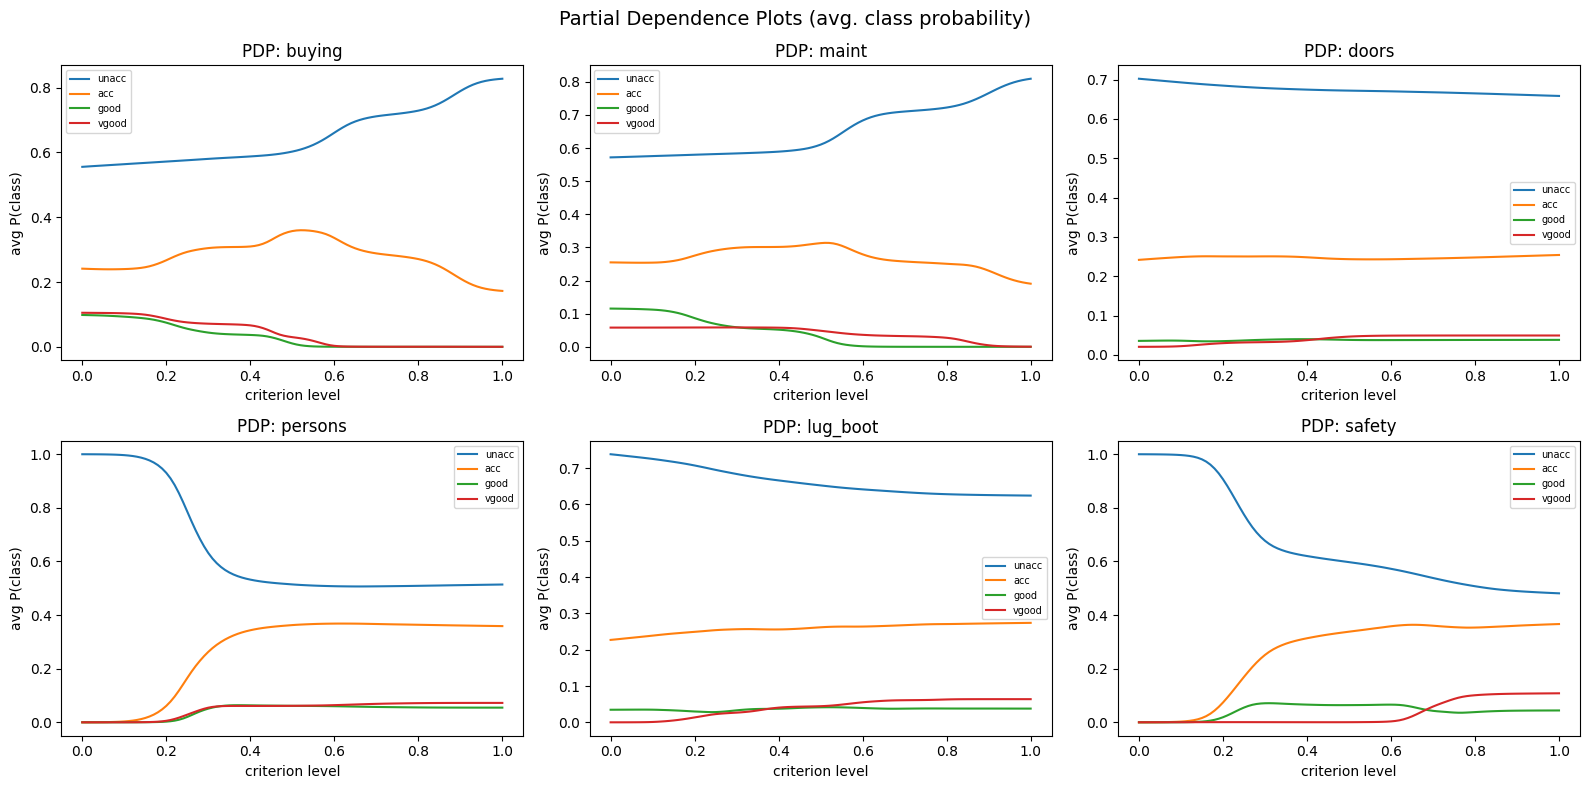

In [22]:
grid_points = np.linspace(0.0, 1.0, 101)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Partial Dependence Plots (avg. class probability)", fontsize=14)

for ci, ax in enumerate(axes.ravel()):
    pdp = np.zeros((len(grid_points), 4))
    for gi, val in enumerate(grid_points):
        X_mod = X_test.copy()
        X_mod[:, ci] = val
        xb = torch.tensor(X_mod, dtype=torch.float32, device=dev)
        with torch.no_grad():
            p = model.predict_proba(xb).cpu().numpy()
        pdp[gi] = p.mean(axis=0)
    for cls_i in range(4):
        ax.plot(grid_points, pdp[:, cls_i], label=class_names[cls_i])
    ax.set_title(f"PDP: {criteria_names[ci]}")
    ax.set_xlabel("criterion level")
    ax.set_ylabel("avg P(class)")
    ax.legend(fontsize=7)

plt.tight_layout()


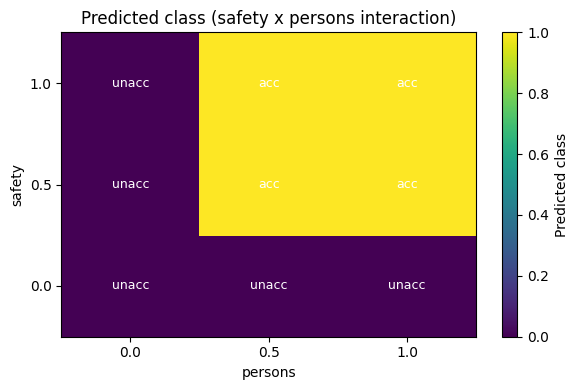

In [23]:
safety_levels = [0.0, 0.5, 1.0]
persons_levels = [0.0, 0.5, 1.0]

baseline = np.median(X_test, axis=0)

heat = np.zeros((len(safety_levels), len(persons_levels)))
for i, s in enumerate(safety_levels):
    for j, p in enumerate(persons_levels):
        probe = baseline.copy()
        probe[5] = s 
        probe[3] = p
        xb = torch.tensor(probe[np.newaxis], dtype=torch.float32, device=dev)
        with torch.no_grad():
            proba = model.predict_proba(xb).cpu().numpy()[0]
        heat[i, j] = proba.argmax()

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(heat, aspect="auto", origin="lower", cmap="viridis")
ax.set_xticks(range(len(persons_levels)), [str(v) for v in persons_levels])
ax.set_yticks(range(len(safety_levels)), [str(v) for v in safety_levels])
ax.set_xlabel("persons")
ax.set_ylabel("safety")
ax.set_title("Predicted class (safety x persons interaction)")
plt.colorbar(im, ax=ax, label="Predicted class")

for i in range(len(safety_levels)):
    for j in range(len(persons_levels)):
        ax.text(j, i, class_names[int(heat[i, j])], ha="center", va="center", color="white", fontsize=9)
plt.tight_layout()


First-layer mean |weight| per criterion:
  buying: 0.2282
  maint: 0.2013
  doors: 0.1133
  persons: 0.1874
  lug_boot: 0.1966
  safety: 0.2490


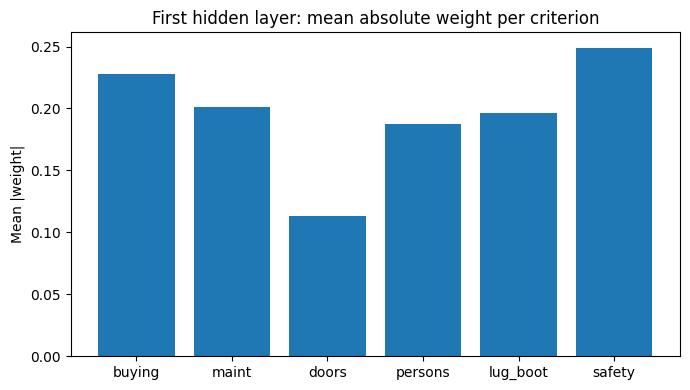

In [24]:
W1 = model.net[0].weight.detach().cpu().numpy() 
abs_w = np.abs(W1).mean(axis=0) 

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(criteria_names, abs_w)
ax.set_ylabel("Mean |weight|")
ax.set_title("First hidden layer: mean absolute weight per criterion")
plt.tight_layout()

print("First-layer mean |weight| per criterion:")
for name, w in zip(criteria_names, abs_w):
    print(f"  {name}: {w:.4f}")


## 2.1 Summary — Explanation of Decisions

For the three selected alternatives (indices `613`, `750`, `1416`):

- Each alternative's predicted class and full class-probability vector were reported.
- **Jacobian** of the predicted-class logit w.r.t. the input reveals which criteria the model is most sensitive to at that specific point. Criteria with large absolute gradient magnitude have the strongest local influence.
- **ICE plots** visualize how sweeping each criterion from 0 to 1 changes the probability distribution over classes. Steep transitions indicate decisive thresholds; flat regions indicate indifference.
- **Minimum single-criterion change to flip class**:
  - *Analytical*: for each criterion, every possible discrete level is tested; the smallest absolute change that flips the prediction is reported.
  - *Sampling*: only immediate neighbor levels are tried.
  - The two approaches are consistent: if a one-step neighbor flips the class, it is also found by the exhaustive analytical search. When no single-criterion change flips the class, the alternative is robustly classified.


## 2.2 Summary — Interpretation of the Model

Based on permutation importance, PDP plots, interaction heatmap, and first-layer weight analysis:

- **User Preferences from model parameters:** The first-layer weight magnitudes and permutation importance both indicate that `safety` and `persons` receive the highest attention from the network, followed by `buying` and `maint`. `doors` has the smallest influence.

- **Decisive vs. negligible criteria:** `safety` and `persons` are decisive — permuting them causes the largest drop in AUC. `doors` has a comparatively negligible effect.

- **Dependencies between criteria:** The interaction heatmap for safety × persons shows a clear non-additive interaction: when both are at their lowest level, the car is unacceptable regardless of other features. Increasing only one of them may not be sufficient to improve the class; both need to be at adequate levels for higher classes. This confirms a synergistic dependency.

- **Nature of criteria (gain, cost, non-monotonic):** PDP plots show that all six criteria act as **gain-type**: increasing the encoded value generally increases the probability of better classes and decreases the probability of `unacc`. The network has learned monotonic-like responses despite having no explicit monotonicity constraint. Some criteria e.g., `doors` show nearly flat PDPs, indicating weak influence.

- **Preference thresholds and indifference zones:** The PDP curves for `safety` and `persons` exhibit sharp transitions step-like behavior around 0.0→0.5, acting as effective veto thresholds: below a certain level the car is almost certainly `unacc`. Above these thresholds, further increase has diminishing returns — an indifference zone. For `buying` and `maint`, the transition is more gradual, indicating softer preferences without hard vetoes.

- **Interpretation techniques used:** Permutation Feature Importance, Partial Dependence Plots, ICE plots, Jacobian-based local sensitivity, interaction heatmap, and first-layer weight analysis.

**Practical takeaway:** The feedforward neural network, despite being a "black-box" model, reveals interpretable structure consistent with the domain: safety and passenger capacity are non-negotiable requirements (veto criteria), while economic factors (buying, maintenance) and comfort (luggage, doors) play secondary roles in determining car acceptability.
